# Mobile Price Range Classification

## Problem Statement

Market size of mobile phones if growing everyday and so is the competition.To capture the maximum market electronics companies try to make improvements in their products. However, sales of mobile phones depend on various factors like demand, technology, marketing, brand, availability, user experience, service, price, etc. As we understand that selling price makes a huge difference when it comes to sales and profits. 
Estimating an optimal price for a new mobile phone can be a tricky task especially when you are new in the business or when you want to launch a new kind of mobile phone in the market. 

As part of this exercise we will try to estimate the price range for a given mobile phone using given feature information. These details are collected from various similar companies.  

## Attribute Information

id : ID

battery_power : Total energy a battery can store in one time measured in mAh

blue : Has bluetooth or not

clock_speed : speed at which microprocessor executes instructions

dual_sim : Has dual sim support or not

fc : Front Camera megapixels

four_g : Has 4G or not

int_memory : Internal Memory in Gigabytes

m_dep : Mobile Depth in cm

mobile_wt : Weight of mobile phone

n_cores : Number of cores of processor

pc : Primary Camera mega pixels

px_height: Pixel Resolution Height

px_width: Pixel Resolution Width

ram: Random Access Memory in Megabytes

sc_h : Screen Height of mobile in cm

sc_w : Screen Width of mobile in cm

talk_time : longest time that a single battery charge will last when you are

three_g : Has 3G or not

touch_screen : Has touch screen or not

wifi : Has wifi or not

price_range : This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).


## Table of Content

1. Import Libraries

2. Setting options

3. Read Data

4. Data Analysis and Preparation

    4.1 - Understanding the Dataset

    4.1.1 - Data Types

    4.1.2 - Summary Statistics

    4.1.3 - Missing Values

    4.1.3 - Missing Values

    4.1.4 - Correlation

    4.1.5 - Discover Outliers with Visualization

    4.1.6 - Visualizing features having strongest relation with target variable

5. Logistic Regression


6. Conclusion and Interpretation

## 1. Import Libraries

In [1]:
# used to supress display of warnings
import warnings

# os is used to provide a way of using operating system dependent functionality
# We use it for setting working folder
import os

# Pandas is used for data manipulation and analysis
import pandas as pd 

# Numpy is used for large, multi-dimensional arrays and matrices, along with mathematical operators on these arrays
import numpy as np

# Matplotlib is a data visualization library for 2D plots of arrays, built on NumPy arrays 
# and designed to work with the broader SciPy stack
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot

# Seaborn is based on matplotlib, which aids in drawing attractive and informative statistical graphics.
import seaborn as sns


## Scikit-learn features various classification, regression and clustering algorithms
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import average_precision_score, confusion_matrix, accuracy_score, classification_report, plot_confusion_matrix


ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/home/prithviraj/anaconda3/lib/python3.7/site-packages/sklearn/metrics/__init__.py)

## 2. Setting Options

In [2]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

## 3. Read Data

In [5]:
# read csv file using pandas
df = pd.read_csv('Mobile.csv')

In [6]:
# to display the top 5 rows of the dataframe
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2000000,0,1,0,7,0.6000000,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5000000,1,0,1,53,0.7000000,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5000000,1,2,1,41,0.9000000,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5000000,0,0,0,10,0.8000000,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2000000,0,13,1,44,0.6000000,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


## 4.  Data Analysis and Preparation

Data preparation is the process of cleaning and transforming raw data prior to building predictive models.

Here we will analyze and prepare data to perform regression techniques:
1. Check dimensions of the dataframe in terms of rows and columns
2. Check data types. Ensure your data types are correct. Refer data definitions to validate
3. If data types are not as per business definition, change the data types as per requirement
4. Study summary statistics
5. Check for missing values
6. Study correlation
7. Detect outliers

Note: it is an art to explore data and one will need more and more practice to gain expertise in this area

In [7]:
# to display the dimension of the dataframe
df.shape

(2000, 21)

#### Dataframe has 21 columns and 2000 rows

In [8]:
# to display the column names of the dataframe
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

## 4.1.1 Data Types

In [9]:
# check the datatypes
df.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

#### From the above output, we see that except for the columns of clock_speed and m_dep all our columns datatype is int64.

#### Categorical columns - blue, dual_sim, four_g, three_g, touch_screen, wifi, price_range 

#### Remaining columns are categorical

### Let's check how the distribution and frequency tabel for these columns

In [10]:
# Check value counts for price range
pd.value_counts(df['price_range'])

3    500
2    500
1    500
0    500
Name: price_range, dtype: int64

#### Classes are balanced

In [11]:
pd.value_counts(df['wifi'])

1    1014
0     986
Name: wifi, dtype: int64

## 4.1.2 Summary Statistics

In [12]:
# describe the numerical data
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000,2000.0000000
mean,1238.5185000,0.4950000,1.5222500,0.5095000,4.3095000,0.5215000,32.0465000,0.5017500,140.2490000,4.5205000,9.9165000,645.1080000,1251.5155000,2124.2130000,12.3065000,5.7670000,11.0110000,0.7615000,0.5030000,0.5070000,1.5000000
std,439.4182061,0.5001000,0.8160042,0.5000348,4.3414437,0.4996625,18.1457150,0.2884155,35.3996549,2.2878367,6.0643149,443.7808108,432.1994469,1084.7320436,4.2132450,4.3563976,5.4639552,0.4262729,0.5001160,0.5000760,1.1183136
min,501.0000000,0.0000000,0.5000000,0.0000000,0.0000000,0.0000000,2.0000000,0.1000000,80.0000000,1.0000000,0.0000000,0.0000000,500.0000000,256.0000000,5.0000000,0.0000000,2.0000000,0.0000000,0.0000000,0.0000000,0.0000000
25%,851.7500000,0.0000000,0.7000000,0.0000000,1.0000000,0.0000000,16.0000000,0.2000000,109.0000000,3.0000000,5.0000000,282.7500000,874.7500000,1207.5000000,9.0000000,2.0000000,6.0000000,1.0000000,0.0000000,0.0000000,0.7500000
50%,1226.0000000,0.0000000,1.5000000,1.0000000,3.0000000,1.0000000,32.0000000,0.5000000,141.0000000,4.0000000,10.0000000,564.0000000,1247.0000000,2146.5000000,12.0000000,5.0000000,11.0000000,1.0000000,1.0000000,1.0000000,1.5000000
75%,1615.2500000,1.0000000,2.2000000,1.0000000,7.0000000,1.0000000,48.0000000,0.8000000,170.0000000,7.0000000,15.0000000,947.2500000,1633.0000000,3064.5000000,16.0000000,9.0000000,16.0000000,1.0000000,1.0000000,1.0000000,2.2500000
max,1998.0000000,1.0000000,3.0000000,1.0000000,19.0000000,1.0000000,64.0000000,1.0000000,200.0000000,8.0000000,20.0000000,1960.0000000,1998.0000000,3998.0000000,19.0000000,18.0000000,20.0000000,1.0000000,1.0000000,1.0000000,3.0000000


#### The above output prints the important summary statistics of all the numeric variables like the mean, median (50%), minimum, and maximum values, along with the standard deviation.

## 4.1.3 Missing Values

In [13]:
# check for missing values
missing_values = df.isnull().sum()

# print the number of missing values of each variable
print(missing_values)

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


#### There are no missing values in the data.

## 4.1.4 Correlation

In [14]:
df.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.0000000,0.0112516,0.0114816,-0.0418468,0.0333344,0.0156646,-0.0040037,0.0340845,0.0018444,-0.0297273,0.0314407,0.0149008,-0.0084018,-0.0006529,-0.0299586,-0.0214209,0.0525104,0.0115222,-0.0105158,-0.0083429,0.2007226
blue,0.0112516,1.0000000,0.0214187,0.0351981,0.0035932,0.0134431,0.0411772,0.0040492,-0.0086046,0.0361607,-0.0099522,-0.0068724,-0.0415334,0.0263509,-0.0029523,0.0006131,0.0139337,-0.0302362,0.0100607,-0.0218632,0.0205729
clock_speed,0.0114816,0.0214187,1.0000000,-0.0013152,-0.0004339,-0.0430734,0.0065451,-0.0143644,0.0123497,-0.0057242,-0.0052450,-0.0145229,-0.0094757,0.0034430,-0.0290776,-0.0073784,-0.0114319,-0.0464335,0.0197558,-0.0244710,-0.0066057
dual_sim,-0.0418468,0.0351981,-0.0013152,1.0000000,-0.0291228,0.0031865,-0.0156790,-0.0221417,-0.0089794,-0.0246581,-0.0171426,-0.0208753,0.0142905,0.0410720,-0.0119493,-0.0166661,-0.0394040,-0.0140076,-0.0171174,0.0227403,0.0174445
fc,0.0333344,0.0035932,-0.0004339,-0.0291228,1.0000000,-0.0165597,-0.0291328,-0.0017911,0.0236180,-0.0133562,0.6445953,-0.0099899,-0.0051756,0.0150990,-0.0110140,-0.0123726,-0.0068286,0.0017926,-0.0148278,0.0200849,0.0219982
four_g,0.0156646,0.0134431,-0.0430734,0.0031865,-0.0165597,1.0000000,0.0086900,-0.0018233,-0.0165367,-0.0297055,-0.0055982,-0.0192362,0.0074482,0.0073135,0.0271655,0.0370050,-0.0466278,0.5842456,0.0167578,-0.0176200,0.0147717
int_memory,-0.0040037,0.0411772,0.0065451,-0.0156790,-0.0291328,0.0086900,1.0000000,0.0068858,-0.0342142,-0.0283104,-0.0332734,0.0104413,-0.0083349,0.0328132,0.0377711,0.0117305,-0.0027903,-0.0093660,-0.0269987,0.0069930,0.0444350
m_dep,0.0340845,0.0040492,-0.0143644,-0.0221417,-0.0017911,-0.0018233,0.0068858,1.0000000,0.0217561,-0.0035039,0.0262824,0.0252629,0.0235663,-0.0094341,-0.0253478,-0.0183881,0.0170026,-0.0120654,-0.0026375,-0.0283527,0.0008530
mobile_wt,0.0018444,-0.0086046,0.0123497,-0.0089794,0.0236180,-0.0165367,-0.0342142,0.0217561,1.0000000,-0.0189888,0.0188439,0.0009393,0.0000898,-0.0025805,-0.0338547,-0.0207605,0.0062085,0.0015506,-0.0143682,-0.0004094,-0.0303022
n_cores,-0.0297273,0.0361607,-0.0057242,-0.0246581,-0.0133562,-0.0297055,-0.0283104,-0.0035039,-0.0189888,1.0000000,-0.0011926,-0.0068721,0.0244799,0.0048683,-0.0003148,0.0258265,0.0131479,-0.0147327,0.0237742,-0.0099635,0.0043993


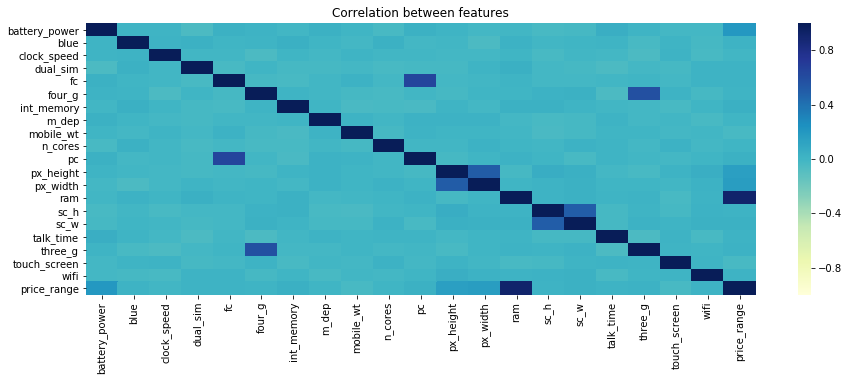

In [17]:
# To get a correlation matrix 
# Ploting correlation plot
corr = df.corr() 
plt.figure(figsize=(15, 5))

# plotting the heat map
# corr: give the correlation matrix
# cmap: colour code used for plotting
# vmax: gives maximum range of values for the chart
# vmin: gives minimum range of values for the chart

sns.heatmap(corr, cmap='YlGnBu', vmax=1.0, vmin=-1.0)

# specify name of the plot
plt.title('Correlation between features')
plt.show()

### Observations

1. We can see that ram is highly correlated with price range
2. four_g and three_g also have some relationship
3. pc ( primary camera) and fc (front camera) are also related
4. Most of the features are not corelated to each other
5. Few features like clock_speed, m_dep, n_cross are not having much relationship with price range and can be dropped

In [18]:
# Check Frequency count between price range and ram
pd.crosstab(df['ram'],df['price_range'])

price_range,0,1,2,3
ram,,,,
256,1,0,0,0
258,2,0,0,0
259,1,0,0,0
262,1,0,0,0
263,1,0,0,0
265,1,0,0,0
267,1,0,0,0
273,1,0,0,0
277,1,0,0,0


### We can see that as 'RAM' increases the price also increases

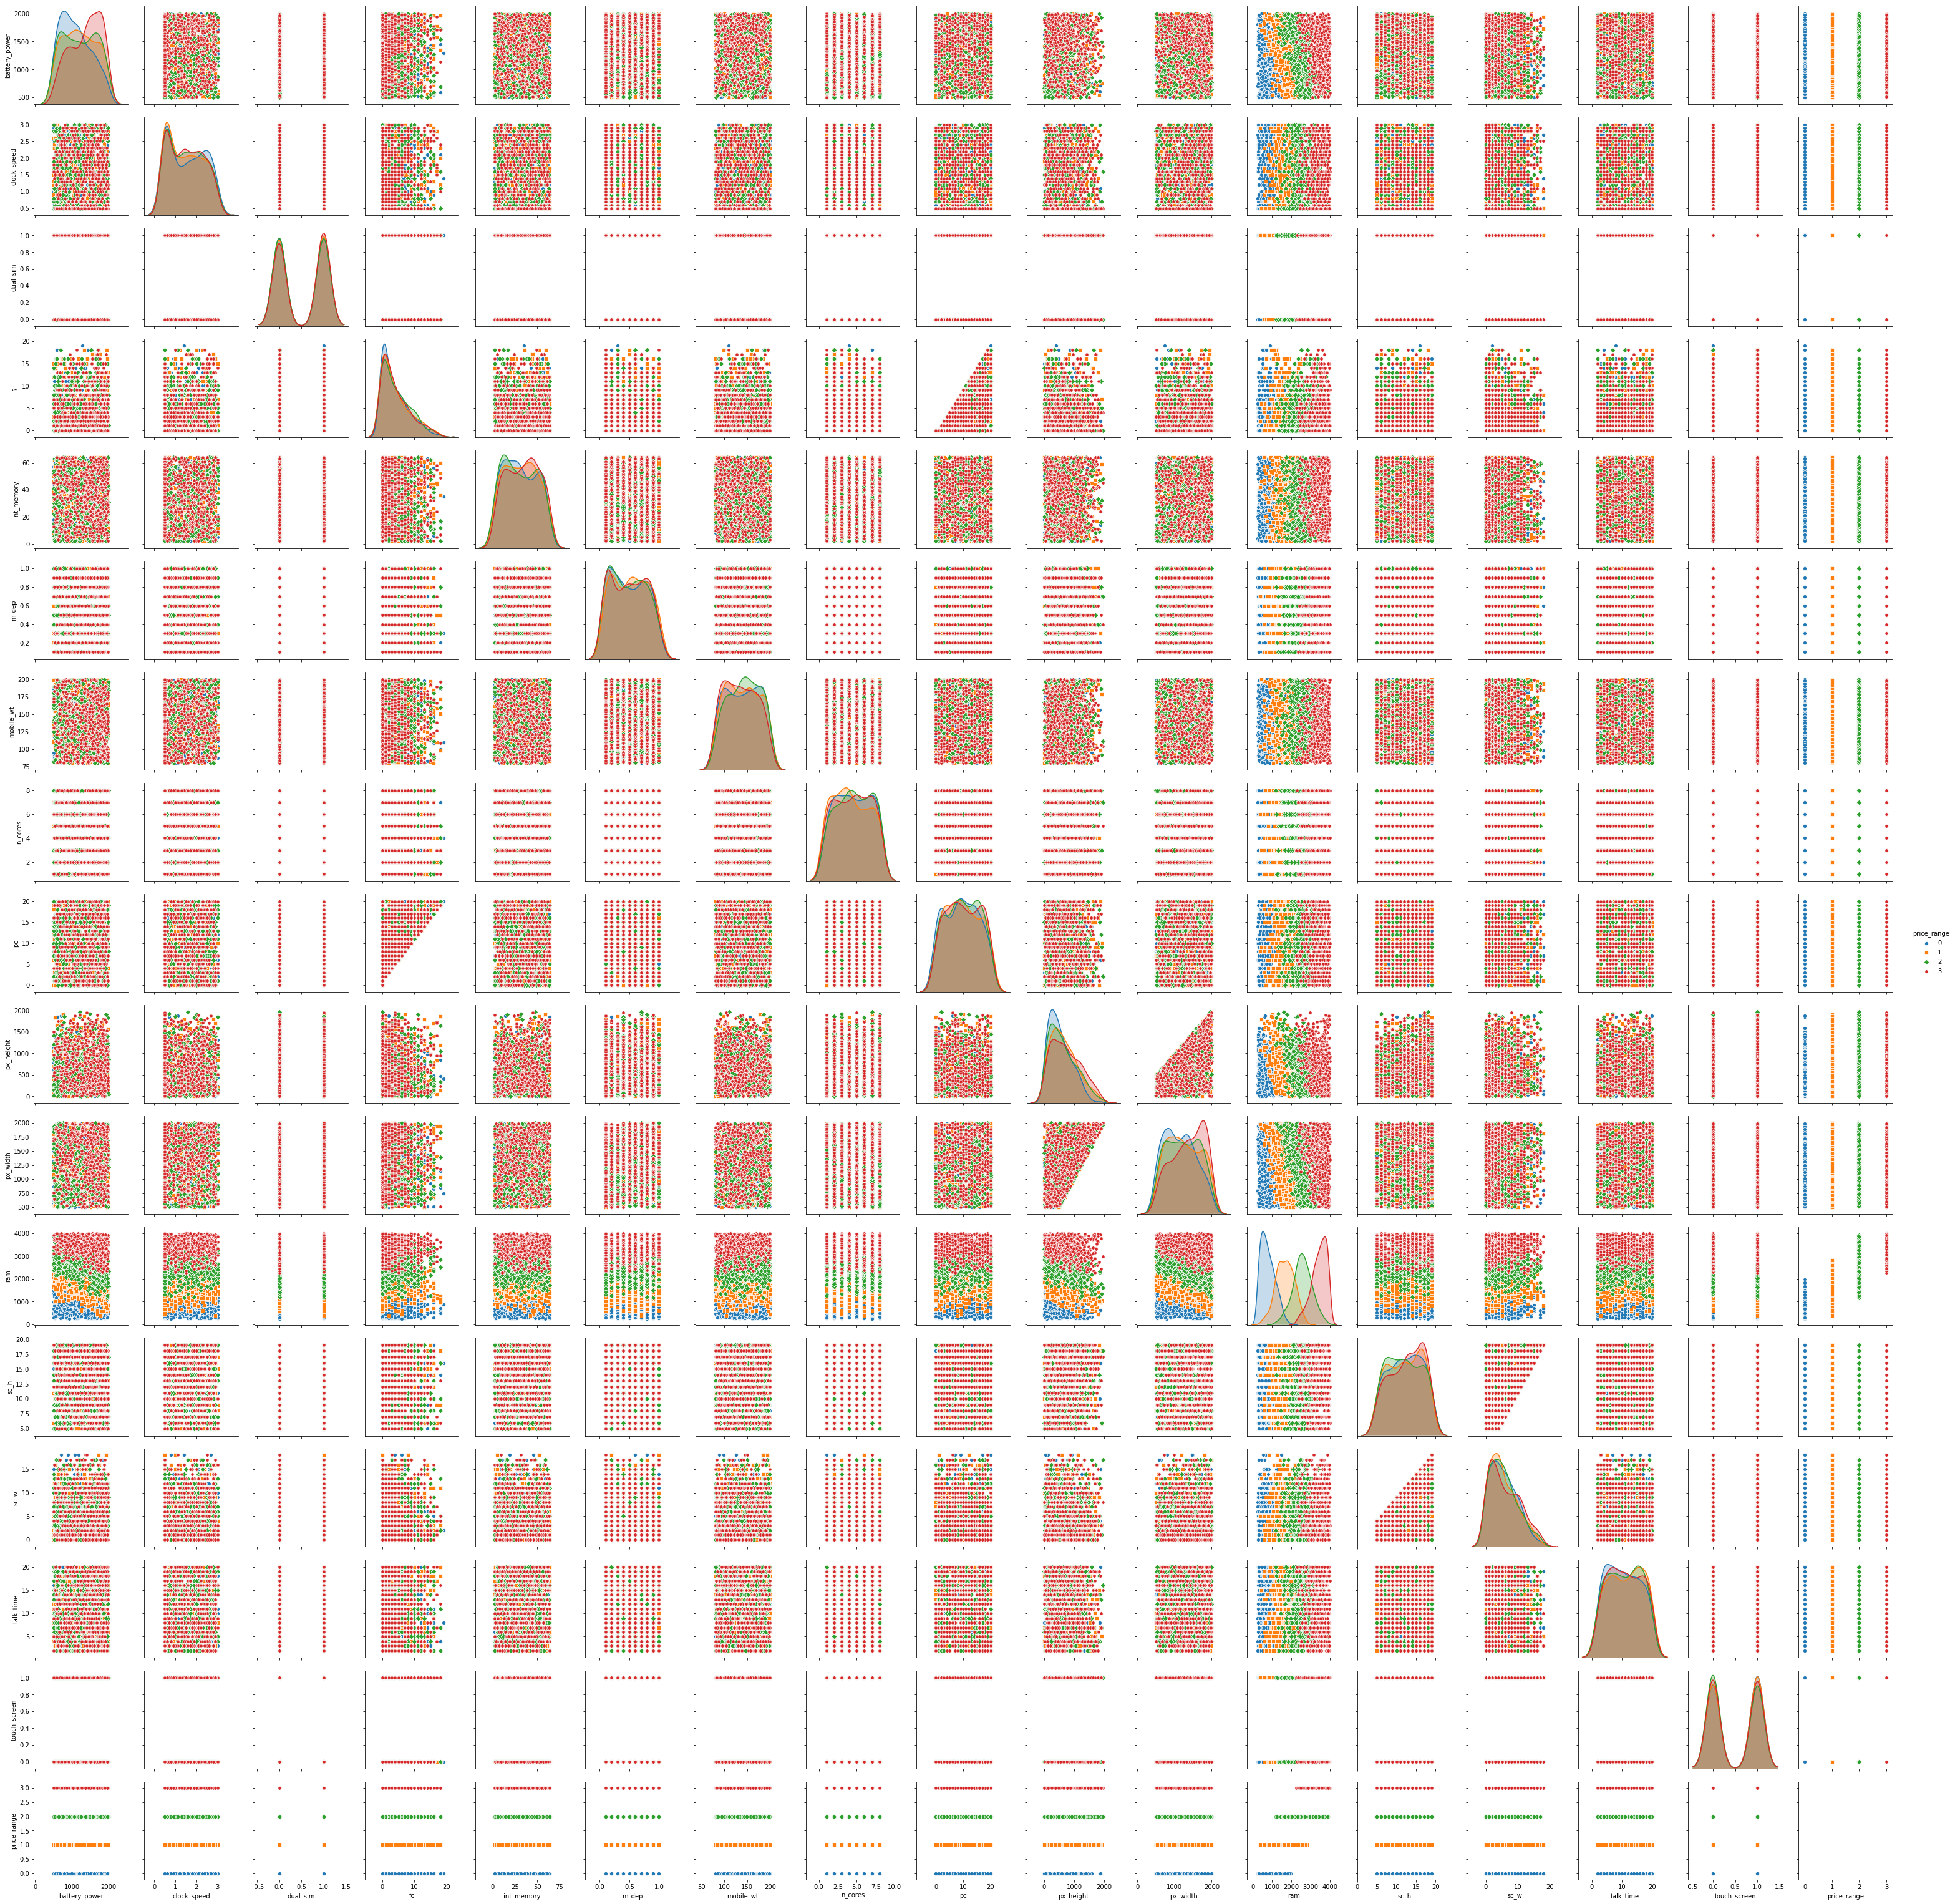

In [19]:
# Check pairplot

dff = df[['battery_power', 'clock_speed', 'dual_sim', 'fc',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 
       'touch_screen', 'price_range']]

sns.pairplot(dff, diag_kind='kde', hue = 'price_range' , markers=["o", "s", "D","h"])
plt.show()

## 4.1.5. Discover Outliers with Visualization

#### Importance of detecting an outlier
One of the most important tasks from large data sets is to find an outlier, which is defined as a sample or event that is very inconsistent with the rest of the data set. The observation point or value would be distant from the other observations in the data set.

Recollect that one of the assumption of Logistic Regression is there should be no outliers

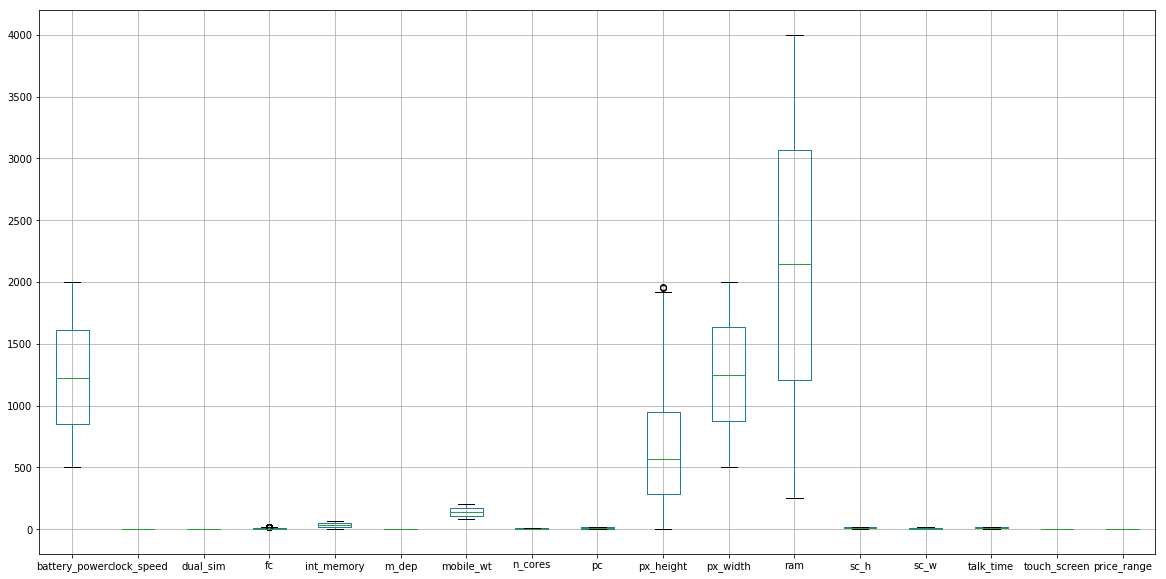

In [20]:
# create a boxplot for all the continuous features
df.boxplot(column = ['battery_power', 'clock_speed', 'dual_sim', 'fc',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 
       'touch_screen', 'price_range'], figsize = (20,10))

In [21]:
df['px_height'].describe()

count   2000.0000000
mean     645.1080000
std      443.7808108
min        0.0000000
25%      282.7500000
50%      564.0000000
75%      947.2500000
max     1960.0000000
Name: px_height, dtype: float64

#### As we know that pixel height can be 1960. There are no outliers.

## 5. Logistic Regression

In [22]:
# Select independent features for model building. ( ID is dropped)
X = df.iloc[:,:20]

y = df['price_range']

# split data into train subset and test subset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# checking the dimensions of the train & test subset
# to print dimension of train set
print(X_train.shape)
# to print dimension of test set
print(X_test.shape)

(1400, 20)
(600, 20)


In [23]:
X.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2000000,0,1,0,7,0.6000000,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5000000,1,0,1,53,0.7000000,136,3,6,905,1988,2631,17,3,7,1,1,0


In [24]:
# import logistic regression and train on tarining set
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=0, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [25]:
# Predict price range of test data
y_pred = model.predict(X_test)
y_pred

array([0, 2, 0, 3, 1, 2, 2, 0, 3, 2, 0, 1, 1, 3, 3, 1, 3, 3, 1, 0, 0, 1,
       2, 2, 0, 2, 3, 3, 2, 0, 0, 0, 3, 0, 2, 1, 2, 0, 3, 0, 2, 3, 3, 0,
       2, 3, 2, 1, 3, 1, 3, 1, 0, 0, 1, 2, 1, 3, 0, 0, 1, 3, 3, 2, 2, 0,
       3, 3, 2, 1, 2, 1, 0, 1, 3, 0, 1, 3, 2, 1, 3, 2, 1, 0, 1, 3, 2, 3,
       3, 0, 3, 3, 2, 1, 3, 1, 2, 3, 2, 1, 0, 0, 1, 0, 1, 3, 2, 0, 2, 1,
       0, 0, 3, 1, 3, 1, 3, 3, 0, 2, 1, 3, 3, 2, 3, 3, 0, 3, 0, 2, 3, 0,
       1, 3, 0, 3, 1, 0, 0, 2, 3, 1, 3, 3, 0, 0, 0, 2, 2, 2, 3, 1, 1, 0,
       2, 3, 0, 1, 0, 2, 2, 3, 3, 1, 1, 0, 0, 2, 2, 2, 3, 0, 0, 0, 3, 1,
       2, 2, 1, 0, 0, 0, 0, 0, 3, 2, 0, 3, 0, 0, 0, 0, 1, 3, 3, 1, 0, 1,
       2, 0, 2, 2, 1, 3, 3, 3, 1, 2, 0, 0, 0, 1, 1, 1, 3, 1, 1, 2, 1, 0,
       3, 1, 3, 0, 0, 2, 0, 3, 0, 0, 1, 0, 1, 3, 2, 1, 1, 2, 3, 0, 2, 3,
       2, 3, 0, 3, 2, 3, 3, 3, 2, 1, 0, 3, 3, 1, 3, 3, 3, 3, 3, 0, 1, 2,
       3, 2, 3, 0, 2, 3, 2, 3, 2, 0, 0, 2, 0, 3, 3, 1, 3, 2, 0, 3, 1, 2,
       0, 0, 3, 0, 1, 2, 3, 3, 3, 1, 1, 0, 1, 3, 3,

In [26]:
# Let's measure the accuracy of this model's prediction
accuracy_score(y_test, y_pred)

0.7766666666666666

In [27]:
# And some other metrics 

print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       151
           1       0.69      0.63      0.66       146
           2       0.63      0.55      0.59       148
           3       0.83      0.97      0.89       155

   micro avg       0.78      0.78      0.78       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.78      0.77       600



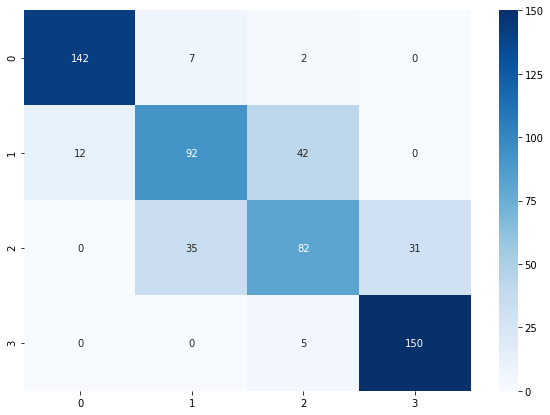

In [28]:
# Display confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
df_conf_mat = pd.DataFrame(conf_mat)
plt.figure(figsize = (10,7))
sns.heatmap(df_conf_mat, annot=True,cmap='Blues', fmt='g')

### Standardize the data

In [29]:
# import zscore for scaling the data
from scipy.stats import zscore

In [30]:
# Apply zscore on independent features
xtrainsc = X_train.apply(zscore)
xtestsc = X_test.apply(zscore)

In [31]:
# Fit the logistic regression model on scaled data 

model1 = LogisticRegression(random_state=0)
model1.fit(xtrainsc, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=0, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [32]:
model1.score(xtrainsc, y_train)

0.8571428571428571

In [33]:
model1.score(xtestsc, y_test)

0.825

In [34]:
ypred = model1.predict(xtestsc)

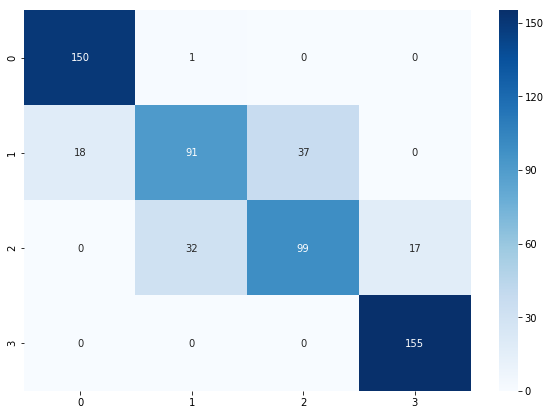

In [35]:
conf_mat = confusion_matrix(y_test, ypred)
df_conf_mat = pd.DataFrame(conf_mat)
plt.figure(figsize = (10,7))
sns.heatmap(df_conf_mat, annot=True,cmap='Blues', fmt='g')

In [36]:
model1.classes_

array([0, 1, 2, 3])

In [37]:
model1.intercept_

array([-5.8696624 , -1.1765486 , -1.1977251 , -5.78787918])

In [38]:
xtestsc.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1860,0.9558543,-0.9966722,1.2411641,-0.9543731,-0.3217990,0.9867544,-0.3688545,0.3798969,1.7063953,-1.0652543,-0.8039873,-0.9890888,0.7897049,-1.3235525,-1.0995713,-0.0080922,-0.0290179,0.5696519,1.0000000,-1.0513150
353,-0.1213434,-0.9966722,-1.2768358,-0.9543731,0.5911060,0.9867544,-1.3198951,0.0340120,-0.0374553,1.5831680,0.9808482,-0.8475941,-0.6364160,0.3992606,1.5355669,2.5351596,1.4527484,0.5696519,-1.0000000,-1.0513150


In [39]:
model1.coef_

array([[-1.70520672e+00,  5.56158513e-02,  1.32276603e-01,
         1.21778355e-01, -9.89359018e-02, -6.26383027e-02,
        -1.62708195e-01, -1.06825919e-01,  2.20365994e-01,
         2.86537631e-02,  4.26206048e-02, -1.08420482e+00,
        -9.09503343e-01, -6.86936523e+00,  4.04998582e-02,
         1.53945037e-02, -1.23034771e-02, -4.22357184e-02,
         6.00581693e-02, -5.37690921e-02],
       [-7.54302203e-02,  5.38280844e-02, -5.51111112e-02,
         6.39671125e-02, -1.05662130e-02,  5.91949614e-02,
         8.71095229e-02,  1.46460792e-01,  1.26949900e-02,
        -6.18847589e-02,  3.71108170e-02,  5.74609213e-02,
         7.05515506e-03, -5.86687965e-01,  3.73979442e-03,
        -5.55209734e-03,  9.54138041e-02, -9.57294041e-03,
         3.36190656e-02,  9.50168369e-02],
       [-1.30778343e-02, -2.52306701e-02,  8.11962839e-03,
        -5.70310596e-02,  8.60109238e-02, -1.43925360e-01,
        -1.79276900e-01, -9.00536672e-02,  1.06991277e-01,
         5.22877920e-02, -1.2

### Here, we can see high correlation with " battery, px_height, px_width, and ram"

## Conclusion

1. We are able to classify price range with an accuracy of 96%
2. 'RAM' seems to be highly correlated with the price range
3. 'battery power' is also an deciding factor of the price
4. Few features like clock_speed, m_dep, n_cross are not having much relationship with price range
5. Standardization of data improves accuracy drastically
6. Few cases were misclassified. However, there were zero misclassification in far classes ( like none of the low cost prices were predicted as high cost). Hence we can say that our model is good for production. 

## Comments

1. This is a classification task hence Logistic Regression is used here. We can apply any other classification algorithms like SVM, Decision Tree, kNN, Naive Bayes etc and compare results.

2. We can see that price range ( dependent variable)  is linearly dependent on a few independent variables like 'RAM', battery, height, width. Hence, it makes sense to use Logistic Regression. 

3. Since Logistic Regression is interpretable, we can infer which features are influencing price range the most. 

